____
# Drifter-altimetry time gap dependency
## 15m - One cycle over two


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, compute_mean_square, drifters_sources, assign_attrs, compute_mean_square_groupby

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

In [5]:
alti_key = 'swot2kmnaive'
f = sorted(glob(os.path.join(zarr_dir, 'save','10days_time_to_swot', f'save_savedeltaT_10days_{alti_key}*_15m.nc')))
dak = xr.open_mfdataset(f).compute()
dak = dak.where(dak.cycle_number%2 == 0, drop=True)#.to_netcdf(os.path.join(zarr_dir, 'save', f'savedeltaT_all_MS_15m_2days_{alti_key}.nc'))


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_40427/3939485857.py:3: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dak = xr.open_mfdataset(f).compute()
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_40427/3939485857.py:3: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dak = xr.open_mfdataset(f).compute()
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_40427/3939485857.py:3: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dak = xr.open_mfdataset(f).compute()


In [6]:
dak

<xarray.Dataset> Size: 1GB
Dimensions:          (id_comb: 3, row_number: 1140696)
Coordinates:
    datetime         (id_comb, row_number) datetime64[ns] 27MB 2023-03-31T16:...
    longitude        (id_comb, row_number) float64 27MB 4.853 4.853 ... 1.748
    latitude         (id_comb, row_number) float64 27MB 42.17 42.17 ... 40.26
    pass_number      (id_comb, row_number) int64 27MB 3 3 3 3 3 ... 16 16 16 16
    time_to_swot     (id_comb, row_number) timedelta64[ns] 27MB 1 days 07:32:...
    cycle_number     (id_comb, row_number) int64 27MB 478 478 478 ... 576 576
    drifter_id       (id_comb, row_number) <U15 205MB '300534060315840' ... '...
    drifter_type     (id_comb, row_number) <U6 82MB 'SVP' 'SVP' ... 'SVP' 'SVP'
    depth            (id_comb, row_number) int64 27MB 15 15 15 15 ... 15 15 15
    phi              (id_comb, row_number) float64 27MB 0.2393 0.2393 ... 2.908
  * row_number       (row_number) int64 9MB 783 784 785 ... 7442943 7442944
  * id_comb          (id_comb) <U48 576B 'nofilter_LF__swot2kmnaive_etaf__rio...
Data variables: (12/31)
    sume             (id_comb, row_number) float64 27MB -5.941e-06 ... 1.379e-05
    acce             (id_comb, row_number) float64 27MB -2.543e-06 ... 2.244e-05
    exce_acc         (id_comb, row_number) float64 27MB -3.399e-06 ... -8.649...
    core             (id_comb, row_number) float64 27MB -2.413e-06 ... -1.413...
    exce_cor         (id_comb, row_number) float64 27MB -3.529e-06 ... 2.792e-05
    ggde             (id_comb, row_number) float64 27MB 2.268e-06 ... 5.402e-06
    ...               ...
    prodn_acc_ggd    (id_comb, row_number) float64 27MB 1.12e-11 ... -5.951e-11
    prodn_acc_wd     (id_comb, row_number) float64 27MB 8.631e-13 ... 8.15e-12
    prodn_cor_ggd    (id_comb, row_number) float64 27MB -1.611e-11 ... 5.87e-11
    prodn_cor_wd     (id_comb, row_number) float64 27MB -1.241e-12 ... -8.039...
    prodn_ggd_wd     (id_comb, row_number) float64 27MB 1.185e-11 ... -2.053e-12
    time_to_swot_1h  (id_comb, row_number) float64 27MB 31.0 31.0 ... 239.0

In [18]:
DAK = []
AK = ['swot2kmnaive', 'L4withswot']
for alti_key in AK:  
    f = sorted(glob(os.path.join(zarr_dir, 'save','10days_time_to_swot', f'save_savedeltaT_10days_{alti_key}*_15m.nc')))
    dak = xr.open_mfdataset(f).compute()
    print(f)
    DAK.append(dak.where(dak.cycle_number%2 == 0, drop=True))


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_43835/123051554.py:5: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dak = xr.open_mfdataset(f).compute()
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_43835/123051554.py:5: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dak = xr.open_mfdataset(f).compute()
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_43835/123051554.py:5: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dak = xr.open_mfdataset(f).compute()


['/Users/mdemol/DATA_MED_COLOC/save/10days_time_to_swot/save_savedeltaT_10days_swot2kmnaive_LF_15m.nc', '/Users/mdemol/DATA_MED_COLOC/save/10days_time_to_swot/save_savedeltaT_10days_swot2kmnaive__15m.nc', '/Users/mdemol/DATA_MED_COLOC/save/10days_time_to_swot/save_savedeltaT_10days_swot2kmnaive_inertial_15m.nc']


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_43835/123051554.py:5: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dak = xr.open_mfdataset(f).compute()
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_43835/123051554.py:5: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dak = xr.open_mfdataset(f).compute()
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_43835/123051554.py:5: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dak = xr.open_mfdataset(f).compute()


['/Users/mdemol/DATA_MED_COLOC/save/10days_time_to_swot/save_savedeltaT_10days_L4withswot_15m.nc', '/Users/mdemol/DATA_MED_COLOC/save/10days_time_to_swot/save_savedeltaT_10days_L4withswot_LF_15m.nc', '/Users/mdemol/DATA_MED_COLOC/save/10days_time_to_swot/save_savedeltaT_10days_L4withswot_inertial_15m.nc']


In [17]:
DAK[0].isel(row_number=0)

<xarray.Dataset> Size: 2kB
Dimensions:          (id_comb: 3)
Coordinates:
    datetime         (id_comb) datetime64[ns] 24B 2023-03-31T16:10:00 ... 202...
    longitude        (id_comb) float64 24B 4.853 4.853 4.853
    latitude         (id_comb) float64 24B 42.17 42.17 42.17
    pass_number      (id_comb) int64 24B 3 3 3
    time_to_swot     (id_comb) timedelta64[ns] 24B 1 days 07:32:32.696536 ......
    cycle_number     (id_comb) int64 24B 478 478 478
    drifter_id       (id_comb) <U15 180B '300534060315840' ... '300534060315840'
    drifter_type     (id_comb) <U6 72B 'SVP' 'SVP' 'SVP'
    depth            (id_comb) int64 24B 15 15 15
    phi              (id_comb) float64 24B 0.2393 0.2393 0.2393
    row_number       int64 8B 783
  * id_comb          (id_comb) <U48 576B 'nofilter_LF__swot2kmnaive_etaf__rio...
Data variables: (12/31)
    sume             (id_comb) float64 24B -5.941e-06 -1.425e-05 -1.669e-06
    acce             (id_comb) float64 24B -2.543e-06 1.071e-05 2.738e-06
    exce_acc         (id_comb) float64 24B -3.399e-06 -2.496e-05 -4.406e-06
    core             (id_comb) float64 24B -2.413e-06 -2.397e-05 -3.42e-06
    exce_cor         (id_comb) float64 24B -3.529e-06 9.725e-06 1.751e-06
    ggde             (id_comb) float64 24B 2.268e-06 2.268e-06 2.268e-06
    ...               ...
    prodn_acc_ggd    (id_comb) float64 24B 1.12e-11 -5.615e-11 3.809e-11
    prodn_acc_wd     (id_comb) float64 24B 8.631e-13 -4.326e-12 2.935e-12
    prodn_cor_ggd    (id_comb) float64 24B -1.611e-11 -7.694e-11 -1.76e-11
    prodn_cor_wd     (id_comb) float64 24B -1.241e-12 -5.928e-12 -1.356e-12
    prodn_ggd_wd     (id_comb) float64 24B 1.185e-11 1.185e-11 1.185e-11
    time_to_swot_1h  (id_comb) float64 24B 31.0 31.0 31.0

## Remove on cycle over two

In [23]:
DAK[0].to_dataframe().reset_index().set_index('row_number')
compute_mean_square_groupby(dff, groupby = 'time_to_swot_1h', compute_error = 'centrallimit')

<xarray.Dataset> Size: 1GB
Dimensions:          (id_comb: 3, row_number: 1140696)
Coordinates:
    datetime         (id_comb, row_number) datetime64[ns] 27MB 2023-03-31T16:...
    longitude        (id_comb, row_number) float64 27MB 4.853 4.853 ... 1.748
    latitude         (id_comb, row_number) float64 27MB 42.17 42.17 ... 40.26
    pass_number      (id_comb, row_number) int64 27MB 3 3 3 3 3 ... 16 16 16 16
    time_to_swot     (id_comb, row_number) timedelta64[ns] 27MB 1 days 07:32:...
    cycle_number     (id_comb, row_number) int64 27MB 478 478 478 ... 576 576
    drifter_id       (id_comb, row_number) <U15 205MB '300534060315840' ... '...
    drifter_type     (id_comb, row_number) <U6 82MB 'SVP' 'SVP' ... 'SVP' 'SVP'
    depth            (id_comb, row_number) int64 27MB 15 15 15 15 ... 15 15 15
    phi              (id_comb, row_number) float64 27MB 0.2393 0.2393 ... 2.908
  * row_number       (row_number) int64 9MB 783 784 785 ... 7442943 7442944
  * id_comb          (id_comb) <U48 576B 'nofilter_LF__swot2kmnaive_etaf__rio...
Data variables: (12/31)
    sume             (id_comb, row_number) float64 27MB -5.941e-06 ... 1.379e-05
    acce             (id_comb, row_number) float64 27MB -2.543e-06 ... 2.244e-05
    exce_acc         (id_comb, row_number) float64 27MB -3.399e-06 ... -8.649...
    core             (id_comb, row_number) float64 27MB -2.413e-06 ... -1.413...
    exce_cor         (id_comb, row_number) float64 27MB -3.529e-06 ... 2.792e-05
    ggde             (id_comb, row_number) float64 27MB 2.268e-06 ... 5.402e-06
    ...               ...
    prodn_acc_ggd    (id_comb, row_number) float64 27MB 1.12e-11 ... -5.951e-11
    prodn_acc_wd     (id_comb, row_number) float64 27MB 8.631e-13 ... 8.15e-12
    prodn_cor_ggd    (id_comb, row_number) float64 27MB -1.611e-11 ... 5.87e-11
    prodn_cor_wd     (id_comb, row_number) float64 27MB -1.241e-12 ... -8.039...
    prodn_ggd_wd     (id_comb, row_number) float64 27MB 1.185e-11 ... -2.053e-12
    time_to_swot_1h  (id_comb, row_number) float64 27MB 31.0 31.0 ... 239.0

In [25]:
D0 = []
for i in range(len(AK)):
    D = []
    for c in DAK[i].id_comb.values :
        dff = DAK[i].sel(id_comb=c).to_dataframe().reset_index().set_index('row_number')
        D.append(compute_mean_square_groupby(dff, groupby = 'time_to_swot_1h', compute_error = 'centrallimit'))
        print(c)
    D0.append(xr.concat(D, pd.Index([ 'LF','All', 'Inertial'], name = 'frequency_band')))
dss = xr.concat(D0, pd.Index(AK , name = 'alti_key'))


X = ['X_acc_cor','X_acc_ggd','X_acc_wd','X_cor_ggd','X_cor_wd','X_ggd_wd']
xstyle = {l.replace('X_', '') : dict(color=c0[l.split('_')[1]], marker="x", markeredgecolor=c0[l.split('_')[2]], markersize=3) for l in X}

dss['sX'] = dss[X[0]]
for x in X[1:]:
    dss['sX']= dss['sX']+dss[x]

dss['time_to_swot_1h'] = (dss.time_to_swot_1h/24).assign_attrs(long_name = 'Drifter-altimetry time gap', units='day')

nofilter_LF__swot2kmnaive_etaf__rio_15era5
nofilter___swot2kmnaive_etaf__rio_15era5
nofilter_inertial__swot2kmnaive_etaf__rio_15era5
nofilter_LF__L4withswot_adt__rio_15era5
nofilter___L4withswot_adt__rio_15era5
nofilter_inertial__L4withswot_adt__rio_15era5


In [26]:
D0[0].isel(time_to_swot_1h=0)

<xarray.Dataset> Size: 3kB
Dimensions:            (frequency_band: 3)
Coordinates:
    time_to_swot_1h    float64 8B 0.0
  * frequency_band     (frequency_band) object 24B 'LF' 'All' 'Inertial'
Data variables: (12/133)
    ACCe               (frequency_band) float64 24B 0.04334 1.143 0.7047
    CORe               (frequency_band) float64 24B 1.281 2.315 0.7106
    GGDe               (frequency_band) float64 24B 1.048 1.048 1.048
    WDe                (frequency_band) float64 24B 0.1686 0.1686 0.1686
    Se                 (frequency_band) float64 24B 1.028 1.185 1.202
    sigmae             (frequency_band) float64 24B 2.541 4.674 2.632
    ...                 ...
    ser__X_acc_wd      (frequency_band) float64 24B 0.006919 0.04271 0.02814
    ser__X_cor_ggd     (frequency_band) float64 24B 0.1418 0.1624 0.07282
    ser__X_cor_wd      (frequency_band) float64 24B 0.05377 0.0865 0.0317
    ser__X_ggd_wd      (frequency_band) float64 24B 0.02568 0.02568 0.02568
    ser__D_cyclo       (frequency_band) float64 24B 0.1361 0.1433 0.02097
    ser__D_anticyclo   (frequency_band) float64 24B 0.1545 0.3071 0.1296

In [29]:
dss['alti_key'] = [ 'L3-2km-SWOT', 'L4-SWOT',]

In [30]:
dss['frequency_band'] = [ 'LF','All', 'Inertial']

In [32]:
dss.to_netcdf(os.path.join(zarr_dir, 'save', 'savedeltaT_all_MS_15m_2days.nc'))

___________
# If already computed 

In [33]:
dss = xr.open_dataset(os.path.join(zarr_dir, 'save', 'savedeltaT_all_MS_15m_2days.nc'))


X = ['X_acc_cor','X_acc_ggd','X_acc_wd','X_cor_ggd','X_cor_wd','X_ggd_wd']
xstyle = {l.replace('X_', '') : dict(color=c0[l.split('_')[1]], marker="x", markeredgecolor=c0[l.split('_')[2]], markersize=3) for l in X}


In [3]:
dss.isel(alti_key=0, time_to_swot_1h=0).ACCe.compute()

<xarray.DataArray 'ACCe' (frequency_band: 3)> Size: 24B
array([0.63039064, 0.63039064, 0.63039064])
Coordinates:
    time_to_swot_1h  float64 8B 0.0
  * frequency_band   (frequency_band) <U8 96B 'LF' 'All' 'Inertial'
    alti_key         <U18 72B 'L3-2km-SWOT'
Attributes:
    long_name:  Zonal Lagrangian acceleration MS

____
# Diag

In [34]:
def plot_error(df, x, v, ax, suf = 'ber__'):
    ax.fill_between(
        df[x], df[v] - df[suf + v], df[v] + df[suf + v], color="silver"
    )
def low_filter(ds, T=2, cutoff = [0.9], vars_ = ['B_ggd', 'E_ggd']+X):
    from scipy import signal
    from scipy.signal import filtfilt
    from scipy.integrate import cumulative_trapezoid
    from scipy.optimize import minimize

    pass_zero = True
    # coefficients
    dt = 1/24  # 1h in days
    numtaps = int(T / dt)
    pass_zero = True
    # filter
    dss = ds.fillna(0)
    taps = signal.firwin(numtaps, cutoff=cutoff, pass_zero=pass_zero, fs=1 / dt, scale=True)
    for v in vars_ : 
        dss[v] = xr.DataArray(
            filtfilt(taps, 1, dss[v]),
            dims=["alti_key", "frequency_band", "time_to_swot_1h"],
            )
    return dss
dsd = low_filter(dss, cutoff = 0.5)    


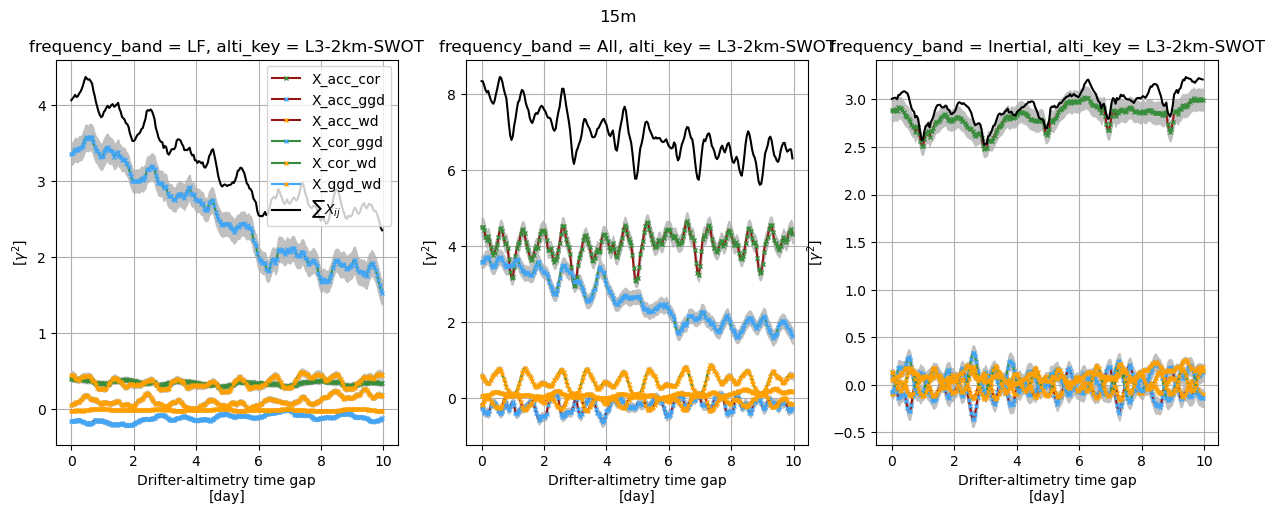

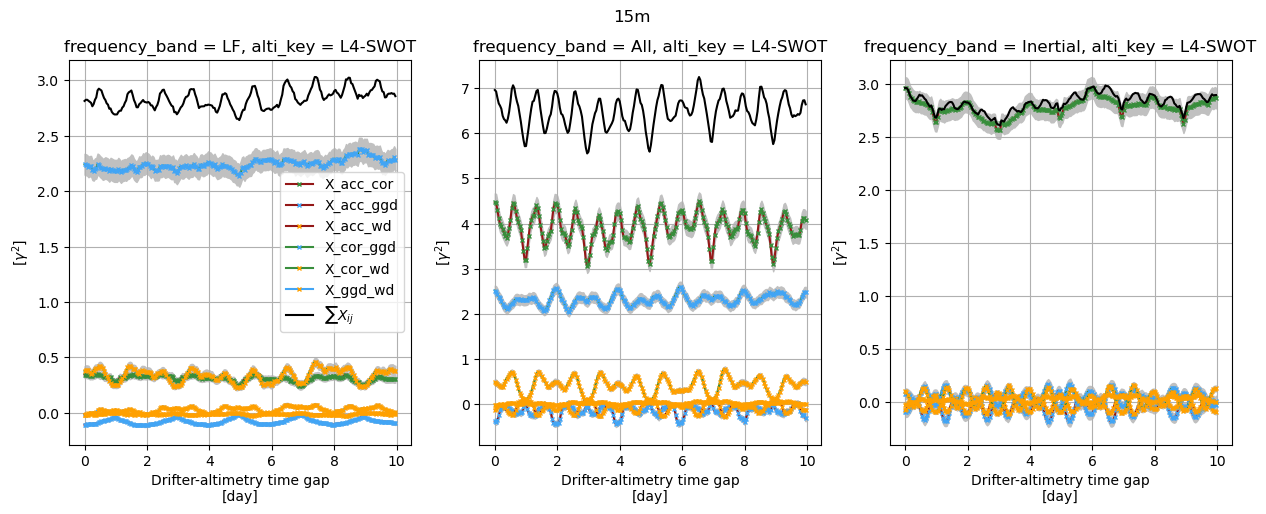

In [35]:
for al in dss.alti_key.values : 
    dss_ = dss.sel(alti_key =al)    
    dsd_ = dsd.sel(alti_key =al)
    fig, axs = plt.subplots(1, 3, figsize=(15,5), frameon=False)
    i=0
    for sp in dss.frequency_band.values : 
        ax=axs[i]
        for x in X :
            dss_.sel(frequency_band = sp)[x].plot(label=x, **xstyle[x.replace('X_', '')], ax=ax)
            #dsd_.sel(frequency_band = sp).isel(time_to_swot_1h= slice(0, None, 12))[x].plot(label=x,**xstyle[x.replace('X_', '')], ax=ax)
            plot_error(dss_.sel(frequency_band = sp),'time_to_swot_1h', x, ax, suf = 'ser__')
        ax.set_title(sp)
        
        dss_.sel(frequency_band = sp).sX.plot(c='k', label = r'$\sum X_{ij}$', ax=ax)
        i+=1
    
    axs[0].legend()
    
    for ax in axs : 
        ax.grid()
        ax.set_ylabel(r'[$\gamma^2$]')

    fig.suptitle('15m')


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_43835/2864864401.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()


Text(0.5, 0.98, '15m')

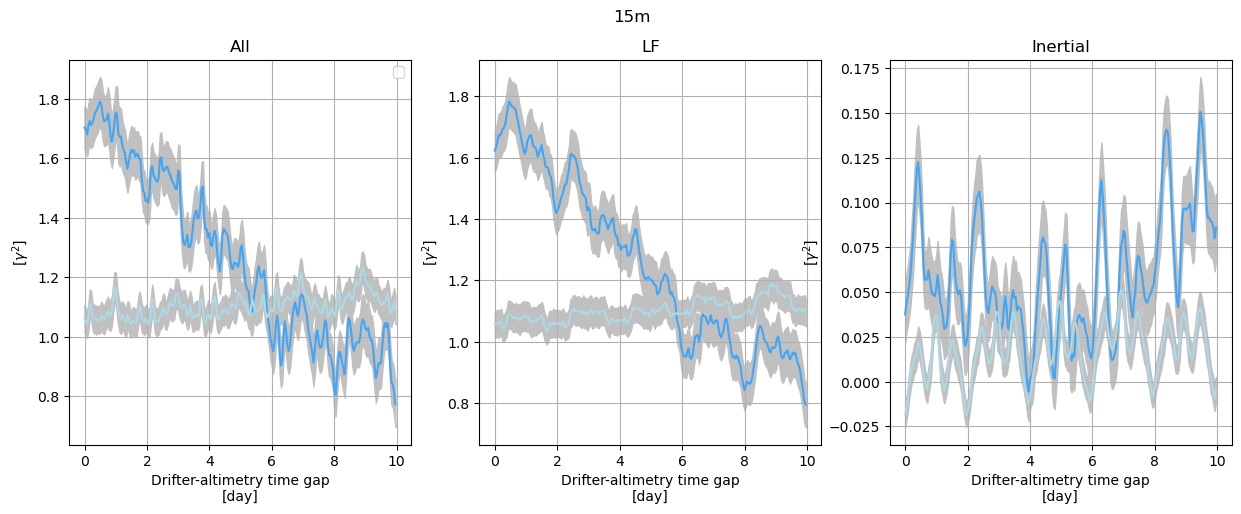

In [37]:

al_color = {'L3-250m-SWOT':'navy', 'L3-2km-SWOT':c0['ggd'],'L4-regional-noSWOT' :'b','L4-global-noSWOT':'teal', 'L4-SWOT':'lightblue'}

fig, axs = plt.subplots(1, 3, figsize=(15,5), frameon=False)#, sharey=True)

for al in dss.alti_key.values :
    dss_ = dss.sel(alti_key =al)    
    dsd_ = dsd.sel(alti_key =al)
    
    for v in ['ggd'] :
        dss_.sel(frequency_band = 'All')['B_'+v].plot( c = al_color[al], ax=axs[0])
        dss_.sel(frequency_band = 'LF')['B_'+v].plot( c = al_color[al], ax=axs[1])
        dss_.sel(frequency_band = 'Inertial')['B_'+v].plot( c = al_color[al], ax=axs[2])
        #dsd_.sel(frequency_band = 'All')['B_'+v].plot(label=al, c = al_color[al], ls='--', ax=axs[0])
        #dsd_.sel(frequency_band = 'LF')['B_'+v].plot(label=al, c = al_color[al], ls='--', ax=axs[1])
        #dsd_.sel(frequency_band = 'Inertial')['B_'+v].plot( label=al, c = al_color[al], ls='--', ax=axs[2])
        plot_error(dss_.sel(frequency_band = 'All'),'time_to_swot_1h','B_'+v, axs[0], suf = 'ser__')
        plot_error(dss_.sel(frequency_band = 'LF'),'time_to_swot_1h', 'B_'+v, axs[1], suf = 'ser__')
        plot_error(dss_.sel(frequency_band = 'Inertial'),'time_to_swot_1h', 'B_'+v, axs[2], suf = 'ser__')
        
    #dss.sel(frequency_band = 'All').sX.plot(c='k', label = r'$\sum X_{ij}$', ax=axs[0])
    #dss.sel(frequency_band = 'LF').sX.plot(c='k', ax=axs[1])
    #dss.sel(frequency_band = 'Inertial').sX.plot(c='k', ax=axs[2])
    
axs[0].legend()

axs[0].set_title('All')
axs[1].set_title('LF')
axs[2].set_title('Inertial')

for ax in axs : 
    ax.grid()
    ax.set_ylabel(r'[$\gamma^2$]')
    #ax.set_xlabel('Drifter-altimetry time gap [h]')

fig.suptitle('15m')


In [38]:
al_color = {'L3-250m-SWOT':'navy', 'L3-2km-SWOT':c0['ggd'],'L4-regional-noSWOT' :'b','L4-global-noSWOT':'teal', 'L4-SWOT':'light_blue'}

1.2890950082486392


/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xrscipy/signal/spectral.py:308: UserWarning: nperseg = 256 is greater than input length  = 240, using nperseg = 240
  f, t, Pxy = _spectral_helper(


Text(0.5, 1.0, '')

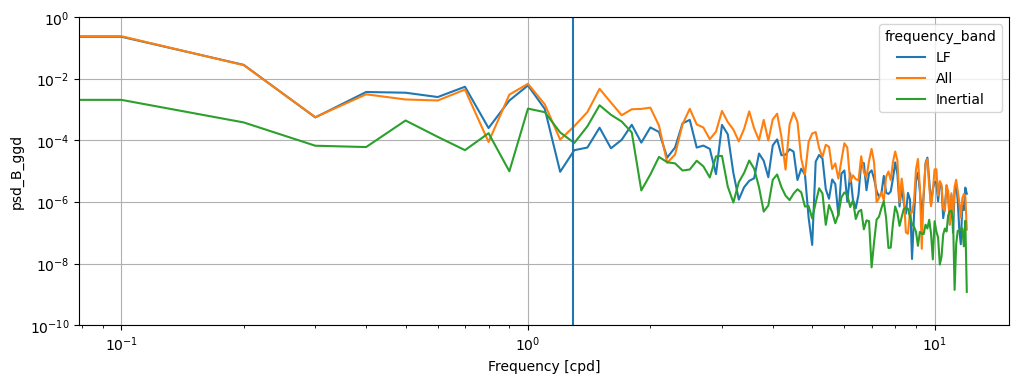

In [39]:
import xrscipy.signal.extra as dsp_extra
psd = dsp_extra.psd(dss.B_ggd, dim="time_to_swot_1h")
fig, ax = plt.subplots(1, 1, figsize=(12, 4), frameon=False)
fc = pyn.geo.coriolis(40) * 86400 / 2 / np.pi
print(fc)
psd.sel(alti_key = 'L3-2km-SWOT').plot(ax=ax, hue='frequency_band')
ax.axvline(abs(fc))
ax.set_xlabel("Frequency [cpd]")
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid()
ax.set_ylim(1e-10, 1e0)
#ax.set_xlim(-24 * 60 / 30 / 2, 24 * 60 / 30 / 2)
ax.set_title("")
